<a href="https://colab.research.google.com/github/mohamadfaisalbashir/scikit-learn-cookbook/blob/main/07_Support_Vector_Machines_and_Kernel_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Support Vector Machines and Kernel Methods**

This notebook covers Support Vector Machines and Kernel Methods:

1. Introduction to SVMs
2. Kernel Functions and Their Applications
3. Tuning SVM Parameters
4. SVMs in High-Dimensional Spaces
5. Evaluating SVM Models

---
# **1. Introduction to Support Vector Machines**

SVMs are versatile ML models used for **classification and regression**. They are particularly effective when:
- The number of features is large relative to the number of samples
- Classes are not linearly separable in the original feature space

## **1.1 Core Concept: The Maximum-Margin Hyperplane**

An SVM finds the **hyperplane** that maximally separates classes by maximizing the **margin** — the distance between the hyperplane and the nearest data points from each class (the **support vectors**).

$$\text{Maximize: } \frac{2}{\|\mathbf{w}\|} \quad \text{Subject to: } y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1$$

## **1.2 Soft Margin**

Real-world data is rarely perfectly separable. SVMs introduce **slack variables** $\xi_i$ to allow some misclassifications — trading off margin size against training error. The `C` hyperparameter controls this trade-off:

- **High C** → strict margin, fewer misclassifications, risk of overfitting  
- **Low C** → wide margin, more tolerant of misclassifications, better generalization

## **1.3 SVC vs. SVR**

| Class | Task | Key Kernel |
|---|---|---|
| `SVC` | Classification | `linear`, `poly`, `rbf`, `sigmoid` |
| `SVR` | Regression | `rbf` (default) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2024
)

# SVM Classifier with linear kernel
svm_clf = SVC(kernel='linear')
svm_clf.fit(X_train, y_train)
y_pred = svm_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"SVM (linear kernel) Accuracy: {accuracy:.2f}")

report_df = pd.DataFrame(
    classification_report(y_test, y_pred, output_dict=True)
).transpose()
print("\nClassification Report:")
print(report_df.round(3).to_string())


SVM (linear kernel) Accuracy: 0.93

Classification Report:
              precision  recall  f1-score  support
0                 1.000   1.000     1.000   18.000
1                 0.909   0.833     0.870   12.000
2                 0.875   0.933     0.903   15.000
accuracy          0.933   0.933     0.933    0.933
macro avg         0.928   0.922     0.924   45.000
weighted avg      0.934   0.933     0.933   45.000


In [2]:
# SVM Regressor with RBF kernel
svm_reg = SVR(kernel='rbf')
svm_reg.fit(X_train[:, :2], y_train)
y_pred_reg = svm_reg.predict(X_test[:, :2])

mse = mean_squared_error(y_test, y_pred_reg)
print(f"SVM Regressor MSE: {mse:.4f}")


SVM Regressor MSE: 0.2037


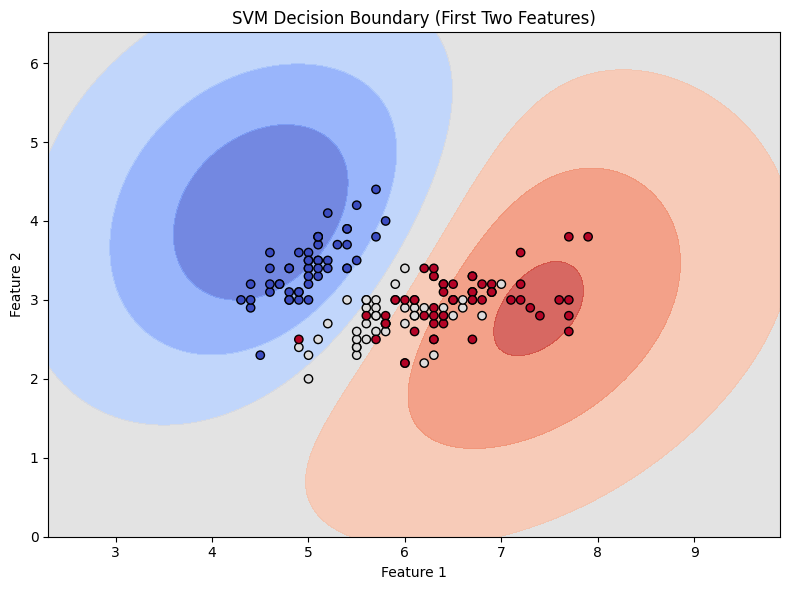

In [3]:
# Visualize SVM decision boundary
from sklearn.inspection import DecisionBoundaryDisplay

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

grid_points = np.c_[xx.ravel(), yy.ravel()]

fig, ax = plt.subplots(figsize=(8, 6))
disp = DecisionBoundaryDisplay.from_estimator(
    svm_reg, grid_points[:, :2],
    response_method="predict", plot_method="contourf",
    cmap=plt.cm.coolwarm, alpha=0.8, ax=ax
)
ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', cmap=plt.cm.coolwarm)
ax.set_title("SVM Decision Boundary (First Two Features)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.tight_layout()
plt.show()


---
# **2. Kernel Functions and Their Applications**

The **kernel trick** is the key insight behind SVMs: rather than explicitly transforming data into a higher-dimensional space, kernels compute the **dot product in that space efficiently**, without ever computing the coordinates.

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)$$

This allows SVMs to find non-linear decision boundaries in the original feature space.

## **2.1 Common Kernel Types**

| Kernel | Formula | Best For |
|---|---|---|
| **Linear** | $\mathbf{x}_i \cdot \mathbf{x}_j$ | Linearly separable data, large feature sets |
| **Polynomial** | $(\gamma \mathbf{x}_i \cdot \mathbf{x}_j + r)^d$ | Data with polynomial feature interactions |
| **RBF (Gaussian)** | $e^{-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2}$ | General-purpose; handles complex boundaries |
| **Sigmoid** | $\tanh(\gamma \mathbf{x}_i \cdot \mathbf{x}_j + r)$ | Neural-network-like behavior |

The **accordion analogy** from the book is useful: the kernel stretches the feature space into a higher dimension (like expanding an accordion), finds a linear boundary there, then collapses it back — leaving a non-linear boundary in the original space.

In [4]:
# Polynomial kernel
svm_poly = SVC(kernel='poly', degree=3)
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
acc_poly = accuracy_score(y_test, y_pred_poly)

# RBF kernel
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"Linear Kernel Accuracy     : {accuracy:.2f}")
print(f"Polynomial Kernel Accuracy : {acc_poly:.2f}")
print(f"RBF Kernel Accuracy        : {acc_rbf:.2f}")


Linear Kernel Accuracy     : 0.93
Polynomial Kernel Accuracy : 0.96
RBF Kernel Accuracy        : 0.91


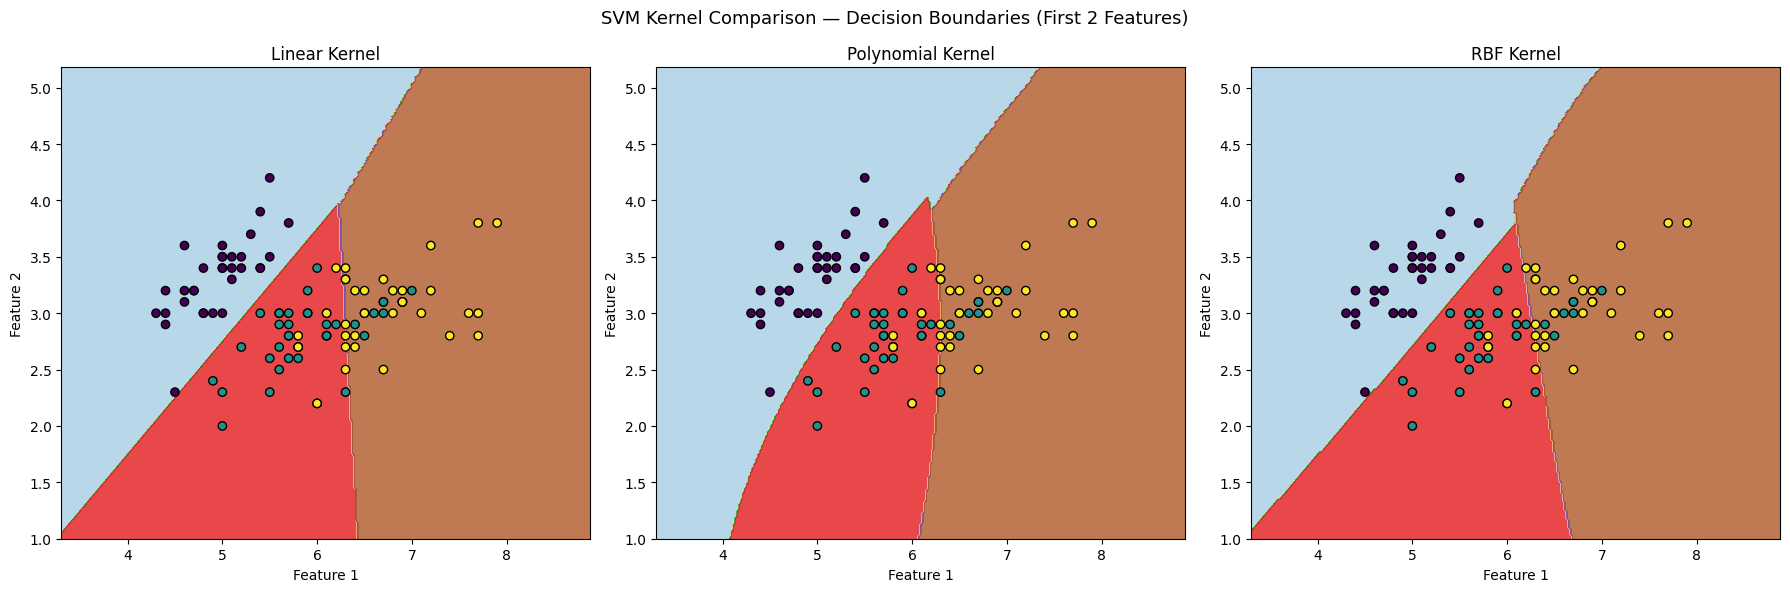

In [5]:
# Visualize decision boundaries for all three kernels (using first 2 features)
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min_b, y_max_b = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx2, yy2 = np.meshgrid(np.arange(x_min, x_max, 0.02),
                       np.arange(y_min_b, y_max_b, 0.02))
X_train_2d = X_train[:, :2]

svm_l2 = SVC(kernel='linear').fit(X_train_2d, y_train)
svm_p2 = SVC(kernel='poly').fit(X_train_2d, y_train)
svm_r2 = SVC(kernel='rbf').fit(X_train_2d, y_train)

grid2d = np.c_[xx2.ravel(), yy2.ravel()]
Z_l = svm_l2.predict(grid2d).reshape(xx2.shape)
Z_p = svm_p2.predict(grid2d).reshape(xx2.shape)
Z_r = svm_r2.predict(grid2d).reshape(xx2.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, Z, title in zip(axes, [Z_l, Z_p, Z_r], ['Linear Kernel','Polynomial Kernel','RBF Kernel']):
    ax.contourf(xx2, yy2, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolors='k', marker='o')
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.suptitle('SVM Kernel Comparison — Decision Boundaries (First 2 Features)', fontsize=13)
plt.tight_layout()
plt.show()


---
# **3. Tuning SVM Parameters**

SVM performance is highly sensitive to hyperparameter choices. The two most important are:

## **3.1 Key Hyperparameters**

| Parameter | Effect | Notes |
|---|---|---|
| `C` | Controls margin vs. misclassification trade-off | Higher C = stricter, smaller margin |
| `kernel` | Determines the feature space transformation | `linear`, `poly`, `rbf`, `sigmoid` |
| `degree` | Polynomial kernel degree | Only relevant for `poly` |
| `gamma` | RBF/Poly kernel width | `scale` (default) or `auto`; affects boundary curvature |

## **3.2 Grid Search with Cross-Validation**

`GridSearchCV` exhaustively evaluates all specified hyperparameter combinations using k-fold cross-validation. It is thorough but computationally expensive — the search space grows multiplicatively with each added parameter.

For large search spaces, `RandomizedSearchCV` samples a fixed number of combinations at random and can often find good solutions faster.

In [6]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C':      [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3, 4]
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters          : {grid_search.best_params_}")
print(f"Best CV Score            : {grid_search.best_score_:.4f}")

# Evaluate best model
best_model = SVC(**grid_search.best_params_)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
print(f"Test Accuracy (Optimized): {accuracy_score(y_test, y_pred_best):.4f}")


Best Parameters          : {'C': 0.1, 'degree': 4, 'kernel': 'poly'}
Best CV Score            : 0.9905
Test Accuracy (Optimized): 0.9333


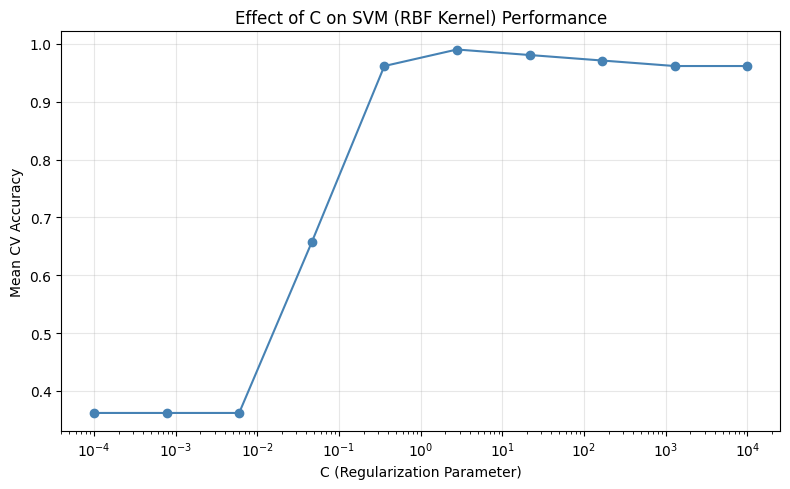

In [7]:
# Visualize effect of C on RBF SVM performance
import warnings
warnings.filterwarnings('ignore')

C_range = np.logspace(-4, 4, 10)
param_grid_c = {'C': C_range, 'kernel': ['rbf']}
gs_c = GridSearchCV(SVC(), param_grid_c, cv=5)
gs_c.fit(X_train, y_train)

plt.figure(figsize=(8, 5))
plt.plot(C_range, gs_c.cv_results_['mean_test_score'], marker='o', color='steelblue')
plt.xscale('log')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Mean CV Accuracy')
plt.title('Effect of C on SVM (RBF Kernel) Performance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
# **4. SVMs in High-Dimensional Spaces**

SVMs are one of the few algorithms that remain effective when the number of **features far exceeds the number of samples** (so-called "wide" datasets). This is because:

1. The kernel trick operates in feature space without explicitly computing coordinates
2. The optimization depends only on **dot products** between training samples
3. Only a small number of **support vectors** define the boundary — not all features

## **4.1 Practical Considerations**

- **Linear kernel** is preferred for very high-dimensional data — it is fast and avoids over-parameterization  
- **Regularization (C)** becomes even more important to prevent overfitting  
- **Dimensionality reduction** (e.g., PCA) can help with visualization, though SVMs generally do not require it for performance

## **4.2 Limitations**

- Training complexity scales roughly as $O(n^2)$ to $O(n^3)$ in samples — SVMs do not scale to very large datasets without approximations  
- The choice of kernel and associated hyperparameters requires careful tuning

In [8]:
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

# Synthetic high-dimensional dataset: 1000 features, 50 informative
X_hd, y_hd = make_classification(
    n_samples=1000, n_features=1000,
    n_informative=50, n_redundant=0, random_state=2024
)

X_tr_hd, X_te_hd, y_tr_hd, y_te_hd = train_test_split(
    X_hd, y_hd, test_size=0.3, random_state=2024
)

# Linear SVM on high-dimensional data
svm_hd = SVC(kernel='linear')
svm_hd.fit(X_tr_hd, y_tr_hd)
y_pred_hd = svm_hd.predict(X_te_hd)
print(f"High-Dimensional SVM Accuracy: {accuracy_score(y_te_hd, y_pred_hd):.4f}")


High-Dimensional SVM Accuracy: 0.7467


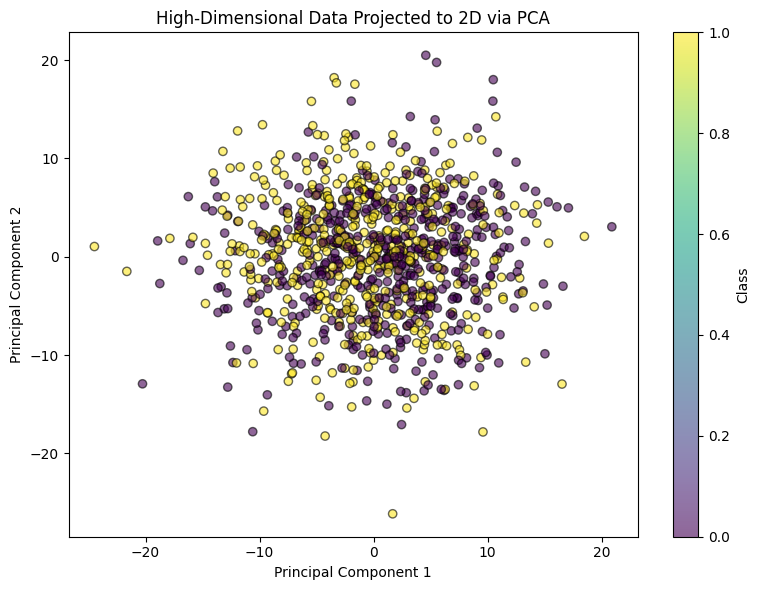

Variance explained by 2 PCs: 4.57%


In [9]:
# PCA projection to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_hd)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_hd, edgecolors='k', alpha=0.6, marker='o')
plt.title('High-Dimensional Data Projected to 2D via PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.2%}")


---
# **5. Evaluating SVM Models**

SVM evaluation follows the same framework as other classifiers. The key addition in this chapter is the **ROC curve** applied to SVMs using predicted probabilities (enabled by `probability=True`).

## **5.1 Enabling Probability Estimates**

By default, SVC does not output probabilities. Setting `probability=True` enables Platt scaling — fitting a logistic regression on top of the SVM scores — at a small computational cost.

## **5.2 ROC Curve Interpretation**

- **X-axis**: False Positive Rate (FPR) = $\frac{FP}{FP + TN}$  
- **Y-axis**: True Positive Rate (TPR / Recall) = $\frac{TP}{TP + FN}$  
- **Diagonal**: Random classifier (AUC = 0.5)  
- **Upper-left corner**: Perfect classifier (AUC = 1.0)

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import roc_curve, auc

data_bc = load_breast_cancer()
X_bc = data_bc.data
y_bc = data_bc.target

X_tr_bc, X_te_bc, y_tr_bc, y_te_bc = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=2024
)

# SVM with probability=True for ROC computation
svm_prob = SVC(kernel='linear', probability=True)
svm_prob.fit(X_tr_bc, y_tr_bc)
y_pred_bc = svm_prob.predict(X_te_bc)
y_prob_bc = svm_prob.predict_proba(X_te_bc)[:, 1]

print(f"SVM (Breast Cancer) Accuracy: {accuracy_score(y_te_bc, y_pred_bc):.4f}")
print("\nClassification Report:")
print(classification_report(y_te_bc, y_pred_bc, target_names=['Malignant','Benign']))


SVM (Breast Cancer) Accuracy: 0.9474

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.93      0.94      0.93        67
      Benign       0.96      0.95      0.96       104

    accuracy                           0.95       171
   macro avg       0.94      0.95      0.94       171
weighted avg       0.95      0.95      0.95       171



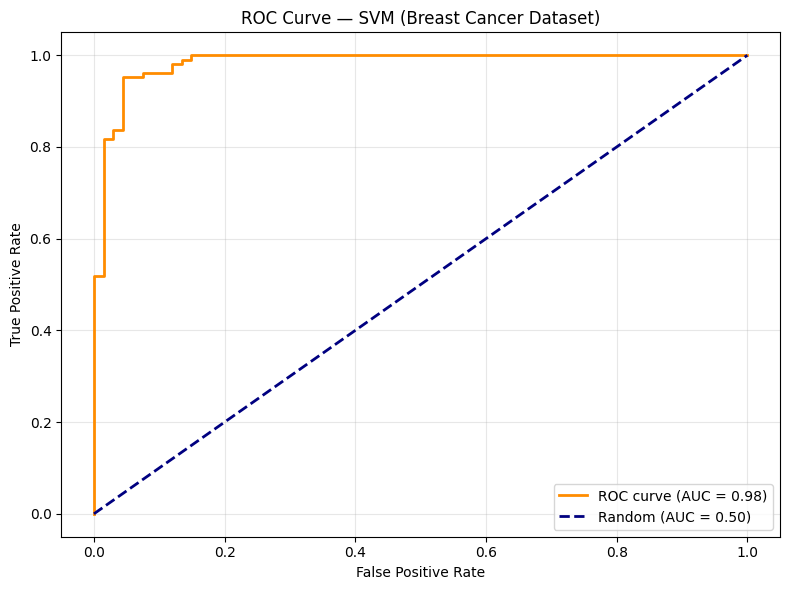

In [11]:
# ROC Curve
fpr_bc, tpr_bc, _ = roc_curve(y_te_bc, y_prob_bc)
roc_auc_bc = auc(fpr_bc, tpr_bc)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bc, tpr_bc, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc_bc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SVM (Breast Cancer Dataset)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
